# ECG Classification - LSTM Model (v3)

LSTM networks are well-suited for sequential data like ECG signals as they can capture temporal dependencies in the heartbeat patterns. This Notebook implement that standard apporach

**Input**: 188 columns of ECG time series data
**Output**: Binary classification (0 = normal, 1 = abnormal)

**Architecture**:
- Bidirectional LSTM: Processes sequence in both directions to capture context from past and future
- Bidirectional(LSTM(64)) → BatchNorm → Dropout(0.3)
- Bidirectional(LSTM(32)) → BatchNorm → Dropout(0.3)
- Dense(64) → Dense(32) → Output
- Preprocessing: StandardScaler normalization (important for RNNs)

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

2025-11-27 06:29:02.433524: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764224942.656025      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764224942.711119      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## Data Loading

In [2]:
# Load data
try:
    df1 = pd.read_csv('/kaggle/input/ecg-dataset/ecg.csv', header=None)
    df2 = pd.read_csv('/kaggle/input/ecg2-dataset/ecg3.csv', header=None)
    df2 = df2.rename(columns={0: 'orig_0'})
    df2.insert(0, 0, df2['orig_0'])
    df2.columns = range(df2.shape[1])
    df = pd.concat([df1, df2], ignore_index=True)
except:
    df = pd.read_csv('../../dataset_aritmia_NEW.csv')

print(f'Dataset shape: {df.shape}')

Dataset shape: (5025, 189)


In [3]:
# Add column names
n_features = df.shape[1] - 1
column_names = [f'f{i}' for i in range(n_features)] + ['label']
df.columns = column_names
print(f'Number of features: {n_features}')
df.head()

Number of features: 188


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f179,f180,f181,f182,f183,f184,f185,f186,f187,label
0,955,954,954,956,958,955,955,953,954,956,...,941,940,940,939,941,941,942,937,938,0
1,952,953,953,953,949,947,953,952,953,952,...,946,949,951,947,948,946,949,949,951,0
2,955,948,952,952,955,955,954,953,955,958,...,939,934,935,934,937,935,930,933,932,0
3,957,958,958,958,956,956,956,959,959,959,...,939,939,942,942,940,938,935,936,937,0
4,958,958,960,960,958,958,959,961,961,961,...,944,946,949,949,950,947,946,946,946,0


In [4]:
# Check label distribution
print('Label distribution:')
print(df['label'].value_counts())
print('\nPercentage:')
print(df['label'].value_counts(normalize=True) * 100)

Label distribution:
label
0    2736
1    2289
Name: count, dtype: int64

Percentage:
label
0    54.447761
1    45.552239
Name: proportion, dtype: float64


## Data Preprocessing

In [5]:
# Prepare features and labels
X = df.drop('label', axis=1).values
y = df['label'].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for LSTM: (samples, timesteps, features)
X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print(f'X shape: {X_scaled.shape}')
print(f'y shape: {y_categorical.shape}')
print(f'Classes: {le.classes_}')

X shape: (5025, 188, 1)
y shape: (5025, 2)
Classes: [0 1]


In [6]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# Compute class weights
y_train_classes = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_classes), y=y_train_classes)
class_weight_dict = dict(enumerate(class_weights))
print(f'Class weights: {class_weight_dict}')
print(f'\nTrain shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Class weights: {0: 0.918227501142074, 1: 1.0977607864554888}

Train shape: (4020, 188, 1)
Test shape: (1005, 188, 1)


## Bidirectional LSTM Model Architecture

In [7]:
def create_lstm_model(input_shape, num_classes):
    model = Sequential([
        # Bidirectional LSTM layer 1
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),
        
        # Bidirectional LSTM layer 2
        Bidirectional(LSTM(32, return_sequences=False)),
        BatchNormalization(),
        Dropout(0.3),
        
        # Dense layers
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    return model

model = create_lstm_model(
    input_shape=(X_train.shape[1], 1),
    num_classes=y_categorical.shape[1]
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1764224956.781876      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764224956.782502      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 188, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 188, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 188, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,338 (321.63 KB)

 Trainable params: 81,826 (319.63 KB)

 Non-trainable params: 512 (2.00 KB)

In [8]:
# Callbacks
callbacks = [
    ModelCheckpoint(
        'ecg_lstm_model.h5',
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

In [9]:
# Train
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/150


I0000 00:00:1764224963.490797     109 cuda_dnn.cc:529] Loaded cuDNN version 90300


126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8058 - loss: 0.4173
Epoch 1: val_loss improved from inf to 0.42286, saving model to ecg_lstm_model.h5


126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8062 - loss: 0.4166 - val_accuracy: 0.8905 - val_loss: 0.4229 - learning_rate: 0.0010
Epoch 2/150
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8838 - loss: 0.2396
Epoch 2: val_loss improved from 0.42286 to 0.19896, saving model to ecg_lstm_model.h5


126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8840 - loss: 0.2393 - val_accuracy: 0.8915 - val_loss: 0.1990 - learning_rate: 0.0010
Epoch 3/150
124/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8956 - loss: 0.2157
Epoch 3: val_loss improved from 0.19896 to 0.16197, saving model to ecg_lstm_model.h5


...

126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9885 - loss: 0.0581 - val_accuracy: 0.9960 - val_loss: 0.0205 - learning_rate: 5.0000e-04
Epoch 16/150
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9853 - loss: 0.0588
Epoch 16: val_loss did not improve from 0.02046
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9853 - loss: 0.0588 - val_accuracy: 0.9960 - val_loss: 0.0243 - learning_rate: 5.0000e-04
Epoch 17/150
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9828 - loss: 0.0623
Epoch 17: val_loss improved from 0.02046 to 0.02012, saving model to ecg_lstm_model.h5


126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9829 - loss: 0.0623 - val_accuracy: 0.9960 - val_loss: 0.0201 - learning_rate: 5.0000e-04
Epoch 18/150
124/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9893 - loss: 0.0500
Epoch 18: val_loss did not improve from 0.02012
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9893 - loss: 0.0503 - val_accuracy: 0.8796 - val_loss: 0.5006 - learning_rate: 5.0000e-04
Epoch 19/150
124/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9660 - loss: 0.1404
Epoch 19: val_loss did not improve from 0.02012
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9664 - loss: 0.1390 - val_accuracy: 0.9930 - val_loss: 0.0365 - learning_rate: 5.0000e-04
Epoch 20/150
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9889 - loss: 0.0489
Epoch 20: val_loss did not improve from 0.02012
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9889 - loss: 0.0488 - val_accuracy: 0.9940 - val_loss: 0.0604 - learning_rate: 5.0000e-04
Epoch

126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9906 - loss: 0.0472 - val_accuracy: 0.9970 - val_loss: 0.0157 - learning_rate: 5.0000e-04
Epoch 22/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9933 - loss: 0.0299
Epoch 22: val_loss did not improve from 0.01573
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9933 - loss: 0.0300 - val_accuracy: 0.9940 - val_loss: 0.0252 - learning_rate: 5.0000e-04
Epoch 23/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9861 - loss: 0.0523
Epoch 23: val_loss did not improve from 0.01573
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9861 - loss: 0.0522 - val_accuracy: 0.9970 - val_loss: 0.0162 - learning_rate: 5.0000e-04
Epoch 24/150
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9949 - loss: 0.0251
Epoch 24: val_loss did not improve from 0.01573
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9948 - loss: 0.0253 - val_accuracy: 0.9861 - val_loss: 0.0586 - learning_rate: 5.0000e-04
Epoch

126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9918 - loss: 0.0410 - val_accuracy: 0.9970 - val_loss: 0.0131 - learning_rate: 2.5000e-04
Epoch 33/150
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9940 - loss: 0.0271
Epoch 33: val_loss did not improve from 0.01308
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9939 - loss: 0.0271 - val_accuracy: 0.9940 - val_loss: 0.0496 - learning_rate: 2.5000e-04
Epoch 34/150
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9901 - loss: 0.0347
Epoch 34: val_loss improved from 0.01308 to 0.01175, saving model to ecg_lstm_model.h5


126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9901 - loss: 0.0346 - val_accuracy: 0.9970 - val_loss: 0.0118 - learning_rate: 2.5000e-04
Epoch 35/150
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9925 - loss: 0.0254
Epoch 35: val_loss did not improve from 0.01175
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9926 - loss: 0.0254 - val_accuracy: 0.9970 - val_loss: 0.0164 - learning_rate: 2.5000e-04
Epoch 36/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9934 - loss: 0.0220
Epoch 36: val_loss did not improve from 0.01175
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9934 - loss: 0.0221 - val_accuracy: 0.9970 - val_loss: 0.0159 - learning_rate: 2.5000e-04
Epoch 37/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9935 - loss: 0.0245
Epoch 37: val_loss did not improve from 0.01175
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9935 - loss: 0.0245 - val_accuracy: 0.9970 - val_loss: 0.0219 - learning_rate: 2.5000e-04
Epoch

## Training Visualization

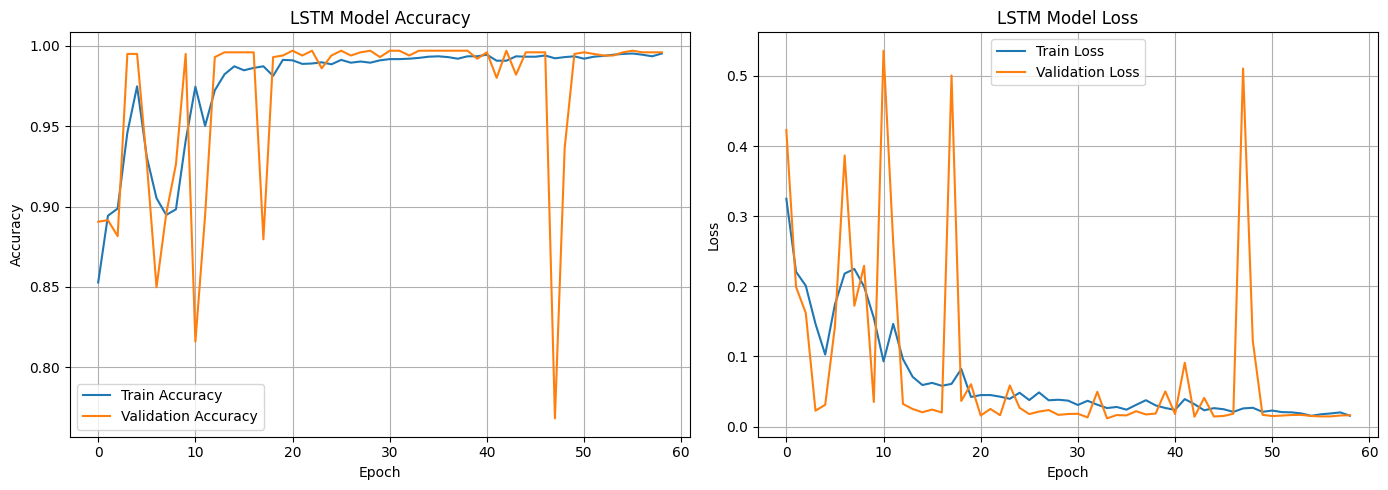

In [10]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('LSTM Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('LSTM Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Model Evaluation

In [11]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'\nTest Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9981 - loss: 0.0087

Test Loss: 0.0118
Test Accuracy: 0.9970


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


<Figure size 800x600 with 0 Axes>

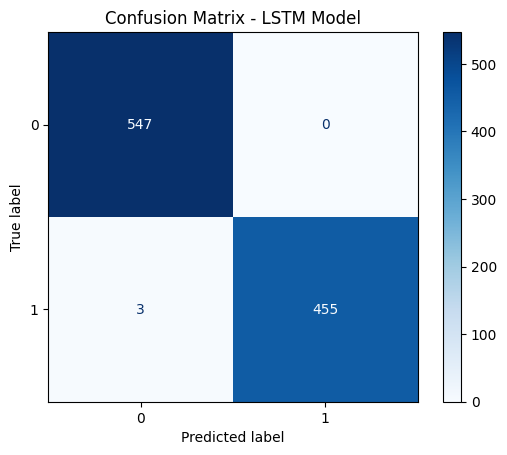

In [12]:
# Predictions and Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - LSTM Model')
plt.show()

In [13]:
# Classification Report
target_names = [str(label) for label in le.classes_]
print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       547
           1       1.00      0.99      1.00       458

    accuracy                           1.00      1005
   macro avg       1.00      1.00      1.00      1005
weighted avg       1.00      1.00      1.00      1005



In [14]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred, multi_class='ovr')
print(f'ROC-AUC Score: {roc_auc:.4f}')

ROC-AUC Score: 0.9998


## Prediction Function

In [15]:
def predict_ecg_lstm(signal, model, scaler, label_encoder):
    signal = np.array(signal).reshape(1, -1)
    signal_scaled = scaler.transform(signal)
    signal_scaled = signal_scaled.reshape(1, -1, 1)
    y_pred = model.predict(signal_scaled, verbose=0)
    predicted_class = np.argmax(y_pred)
    confidence = np.max(y_pred)
    predicted_label = label_encoder.inverse_transform([predicted_class])[0]
    return predicted_label, confidence

In [16]:
# Test prediction with sample data (baseline ~958, peaks during beats)
sample_data = [
    952, 954, 956, 955, 955, 953, 952, 952, 951, 955, 953, 954, 952, 953, 952, 955,
    957, 958, 958, 962, 963, 964, 963, 965, 963, 967, 969, 971, 973, 973, 972, 971,
    973, 973, 972, 968, 966, 968, 970, 973, 969, 966, 960, 964, 965, 970, 971, 970,
    967, 964, 962, 961, 960, 954, 950, 951, 951, 951, 950, 950, 950, 948, 952, 949,
    949, 944, 940, 943, 944, 947, 948, 944, 941, 943, 945, 945, 945, 942, 938, 936,
    933, 926, 927, 920, 910, 909, 919, 940, 963, 986, 1020, 1068, 1121, 1167, 1193,
    1201, 1182, 1136, 1069, 1010, 967, 939, 924, 914, 917, 924, 931, 934, 934, 937,
    940, 942, 942, 941, 940, 939, 940, 938, 938, 936, 934, 934, 938, 938, 938, 935,
    935, 936, 939, 938, 938, 939, 935, 935, 938, 937, 937, 935, 935, 937, 938, 939,
    938, 938, 936, 940, 938, 939, 938, 936, 936, 938, 938, 941, 939, 938, 933, 935,
    935, 938, 938, 936, 936, 937, 938, 941, 941, 939, 939, 940, 943, 943, 941, 941,
    939, 938, 943, 943, 943, 943, 938, 941, 942, 941, 938, 935, 931, 932
]

predicted_label, confidence = predict_ecg_lstm(sample_data, model, scaler, le)
print(f'Prediction: {predicted_label}')
print(f'Confidence: {confidence:.4f}')
print(f'Expected: Normal (0)')

Prediction: 0
Confidence: 0.9998
Expected: Normal (0)


## Save Model

In [18]:
# Save the final model
model.save('ecg_lstm_final.h5')
print('model saved')

model saved
